# 🏥 Système Intelligent de Validation et de Diagnostic d'Analyses Médicales
### Basé sur l'Apprentissage Automatique — Projet ML

**Module :** Machine Learning &nbsp;|&nbsp; **Domaine :** Santé  
**Dataset diagnostic :** Pima Indians Diabetes Dataset (Kaggle)  
**Dataset qualité :** Semi-synthétique (règles biologiques réelles)

---

## 🏗️ Architecture du Système

```
Entrée utilisateur
       │
       ▼
┌─────────────────────┐
│  Modèle 2 : Qualité │  ← délai, température, qualité échantillon
│  Valide / Erronée   │
└─────────────────────┘
       │
  ┌────┴────┐
  │         │
Erronée   Valide
  │         │
  ▼         ▼
⚠️ Bloquer  ┌─────────────────────┐
résultat   │ Modèle 1 : Diagnostic│  ← glucose, BMI, pression...
           │ Diabétique / Non     │
           └─────────────────────┘
```

## 📋 Plan du Notebook
1. Imports & Configuration  
2. **Partie A — Modèle Diagnostic**  
   - 2.1 Chargement & EDA  
   - 2.2 Nettoyage des données  
   - 2.3 Prétraitement  
   - 2.4 Entraînement des 5 algorithmes  
   - 2.5 Optimisation GridSearchCV  
   - 2.6 Comparaison & sélection  
3. **Partie B — Modèle Qualité Labo**  
   - 3.1 Génération du dataset semi-synthétique  
   - 3.2 EDA & visualisations  
   - 3.3 Entraînement des 5 algorithmes  
   - 3.4 Comparaison & sélection  
4. Sauvegarde des artefacts  
5. Test de la logique finale (filtre qualité → diagnostic)


## 1. Imports & Configuration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier, plot_tree
from sklearn.ensemble        import RandomForestClassifier
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.svm             import SVC
from sklearn.metrics         import (classification_report, confusion_matrix,
                                     accuracy_score, f1_score, precision_score,
                                     recall_score, ConfusionMatrixDisplay)
import joblib, os

# ── Style ────────────────────────────────────────────────────────
plt.rcParams.update({'figure.facecolor':'#f9fafb','axes.facecolor':'#ffffff',
                     'axes.grid':True,'grid.alpha':0.3,'axes.spines.top':False,
                     'axes.spines.right':False})
sns.set_palette("Set2")
COLORS = {'pos':'#e74c3c','neg':'#2ecc71','warn':'#f39c12','blue':'#3498db'}

print("✅ Imports OK")
print("   scikit-learn | pandas | numpy | matplotlib | seaborn | joblib")


✅ Imports OK
   scikit-learn | pandas | numpy | matplotlib | seaborn | joblib


---
## PARTIE A — Modèle 1 : Diagnostic du Diabète
> **Dataset réel :** Pima Indians Diabetes Dataset (Kaggle)  
> **Tâche :** Classification binaire — `0 = Non diabétique` / `1 = Diabétique`  
> **Entrées :** Grossesses, Glucose, Pression artérielle, Épaisseur cutanée, Insuline, IMC, Antécédents familiaux, Âge


### 2.1 Chargement & Exploration (EDA)

In [4]:
# ── Chargement ───────────────────────────────────────────────────
df = pd.read_csv('diabetes.csv')
print(f"Dimensions : {df.shape[0]} patients × {df.shape[1]} colonnes")
print(f"Variables  : {list(df.columns)}")
print(f"\nTypes :")
print(df.dtypes)


Dimensions : 768 patients × 9 colonnes
Variables  : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Types :
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [5]:
print("Aperçu des premières lignes :")
df.head(10)


Aperçu des premières lignes :


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [6]:
print("Statistiques descriptives :")
df.describe().round(2)


Statistiques descriptives :


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


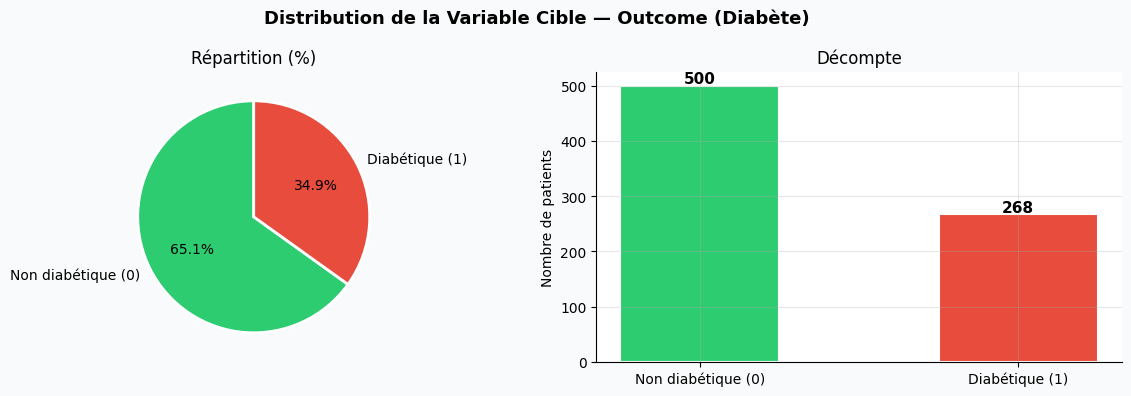


⚠️  Dataset déséquilibré : 500 non-diabétiques vs 268 diabétiques
   → Utiliser le F1 Score et le Rappel, pas seulement l'Accuracy


In [7]:
# ── Distribution de la cible ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Distribution de la Variable Cible — Outcome (Diabète)", fontsize=13, fontweight='bold')

vc = df['Outcome'].value_counts()
labels = ['Non diabétique (0)', 'Diabétique (1)']
colors = [COLORS['neg'], COLORS['pos']]

axes[0].pie(vc.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Répartition (%)')

bars = axes[1].bar(labels, vc.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, v in zip(bars, vc.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+4,
                 str(v), ha='center', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Nombre de patients')
axes[1].set_title('Décompte')

plt.tight_layout()
plt.show()

print(f"\n⚠️  Dataset déséquilibré : {vc[0]} non-diabétiques vs {vc[1]} diabétiques")
print("   → Utiliser le F1 Score et le Rappel, pas seulement l'Accuracy")


In [9]:
# ── Détection des zéros biologiquement impossibles ───────────────
print("Colonnes avec des zéros biologiquement IMPOSSIBLES :")
print("(Un glucose, BMI ou pression artérielle à 0 est physiologiquement impossible)")
print()

cols_impossible = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in cols_impossible:
    n_zeros = (df[col] == 0).sum()
    pct = n_zeros / len(df) * 100
    status = "⚠️ " if n_zeros > 0 else "✅"
    print(f"  {status} {col:30s}: {n_zeros:3d} zéros ({pct:.1f}%) → traités comme NaN")


Colonnes avec des zéros biologiquement IMPOSSIBLES :
(Un glucose, BMI ou pression artérielle à 0 est physiologiquement impossible)

  ⚠️  Glucose                       :   5 zéros (0.7%) → traités comme NaN
  ⚠️  BloodPressure                 :  35 zéros (4.6%) → traités comme NaN
  ⚠️  SkinThickness                 : 227 zéros (29.6%) → traités comme NaN
  ⚠️  Insulin                       : 374 zéros (48.7%) → traités comme NaN
  ⚠️  BMI                           :  11 zéros (1.4%) → traités comme NaN


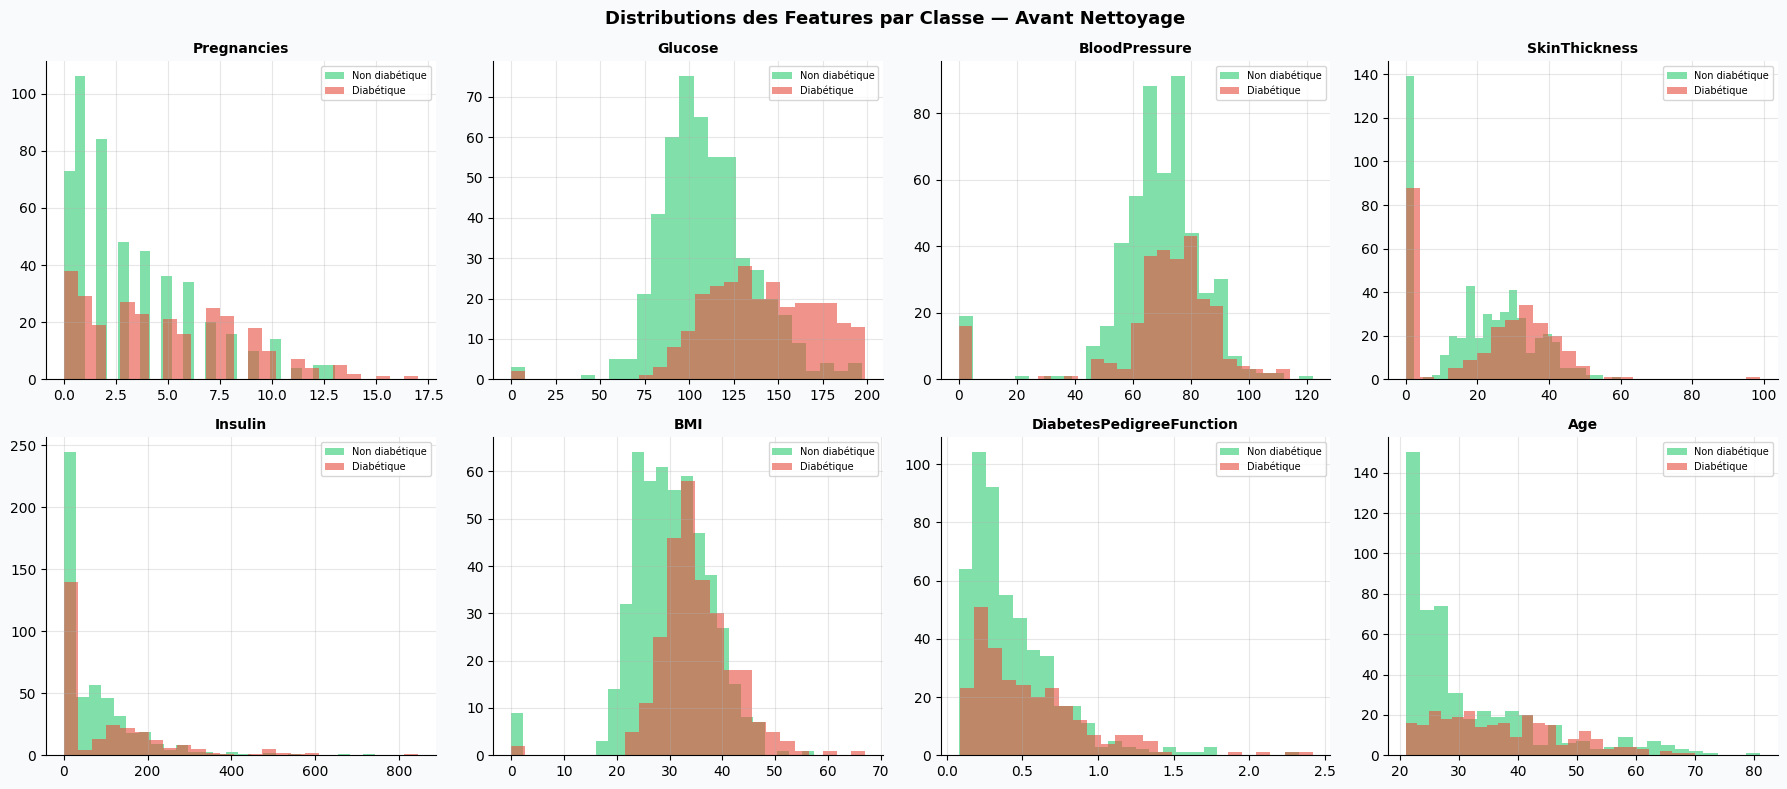

In [10]:
# ── Distributions par classe (avant nettoyage) ───────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Distributions des Features par Classe — Avant Nettoyage", fontsize=13, fontweight='bold')

features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigreeFunction','Age']
labels_map = {0:'Non diabétique', 1:'Diabétique'}
c_map      = {0:COLORS['neg'], 1:COLORS['pos']}

for ax, feat in zip(axes.flat, features):
    for outcome in [0, 1]:
        data = df[df['Outcome']==outcome][feat]
        ax.hist(data, bins=25, alpha=0.6, label=labels_map[outcome],
                color=c_map[outcome], edgecolor='none')
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()


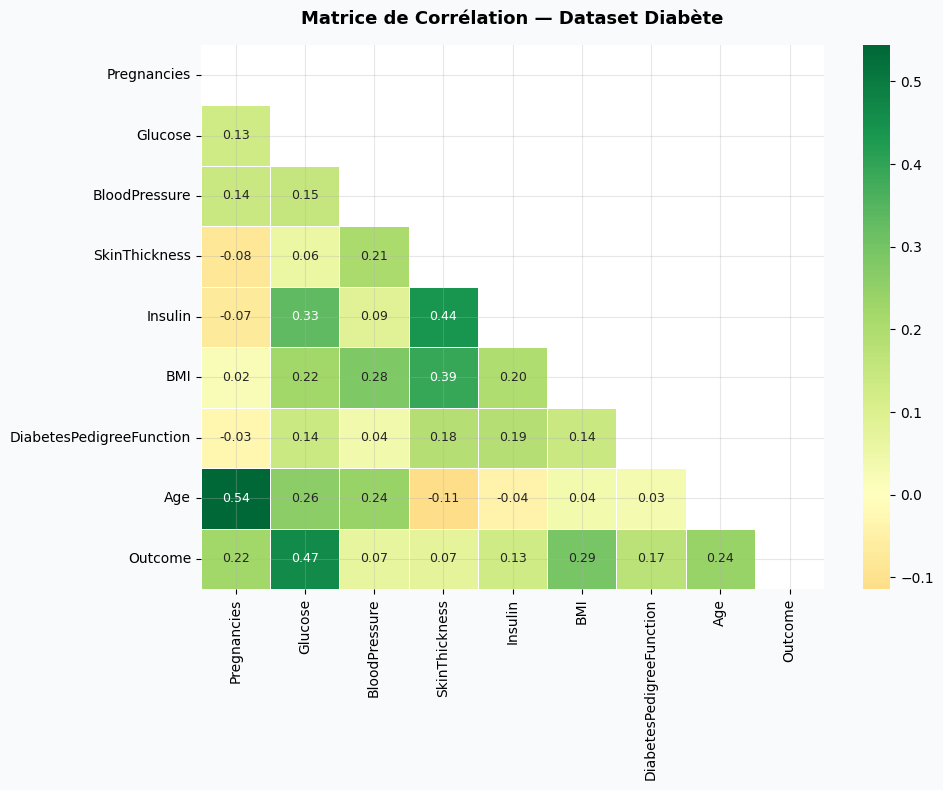


Observation : Glucose est le marqueur le plus corrélé avec le diabète (0.49)
              BMI et Age montrent aussi une corrélation notable.


In [11]:
# ── Matrice de corrélation ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size':9})
ax.set_title("Matrice de Corrélation — Dataset Diabète", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\nObservation : Glucose est le marqueur le plus corrélé avec le diabète (0.49)")
print("              BMI et Age montrent aussi une corrélation notable.")


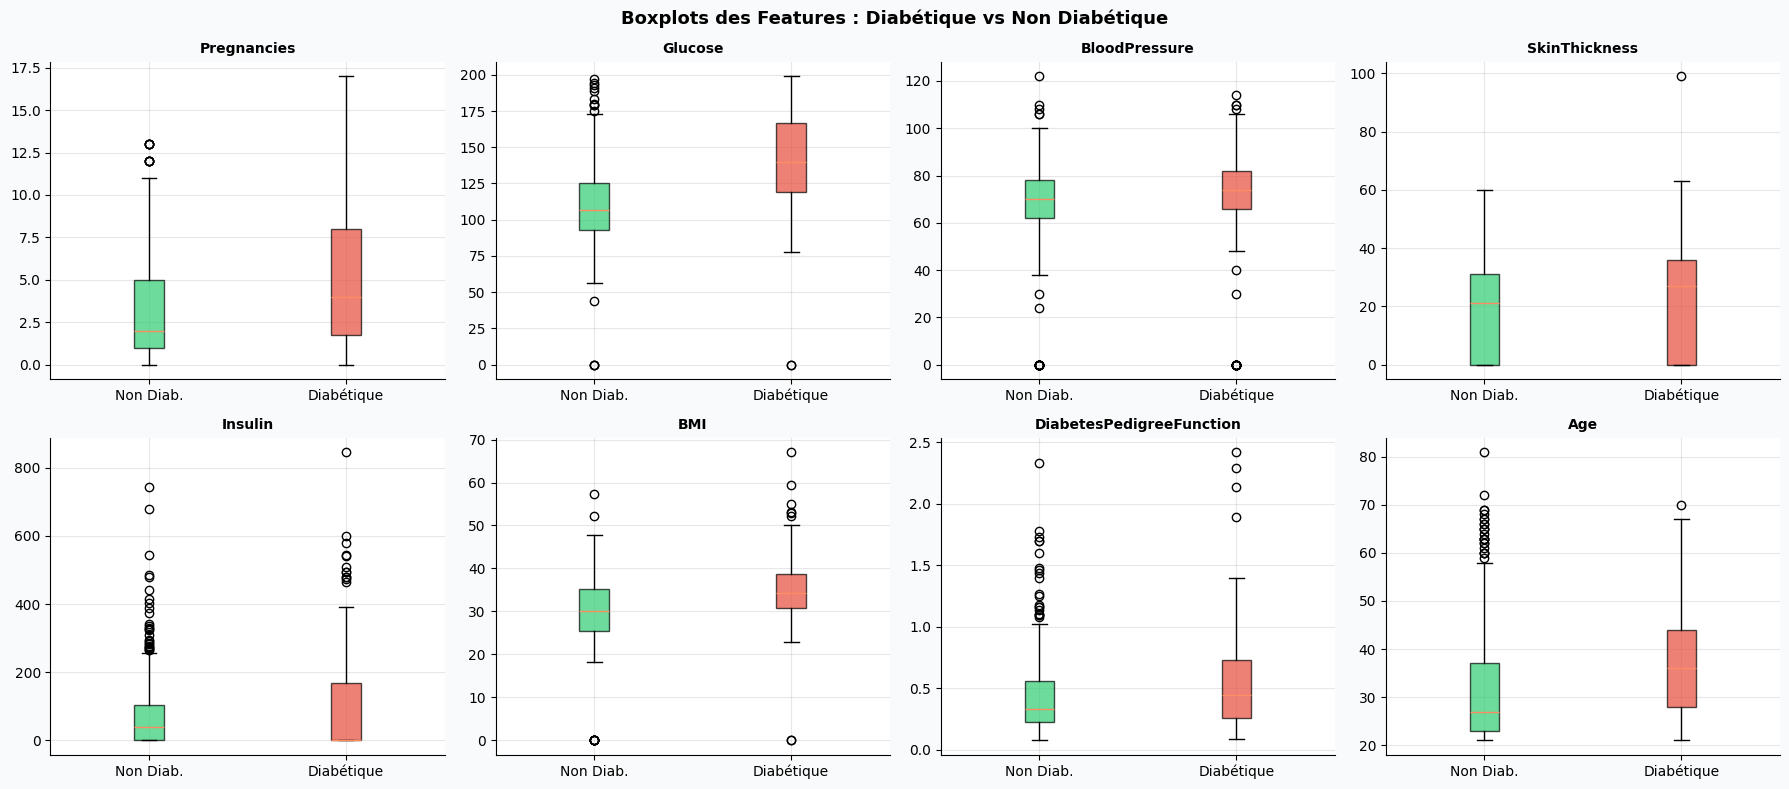

In [12]:
# ── Boxplots par classe ───────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Boxplots des Features : Diabétique vs Non Diabétique", fontsize=13, fontweight='bold')

for ax, feat in zip(axes.flat, features):
    data_groups = [df[df['Outcome']==0][feat], df[df['Outcome']==1][feat]]
    bp = ax.boxplot(data_groups, labels=['Non Diab.','Diabétique'],
                    patch_artist=True, notch=False)
    for patch, color in zip(bp['boxes'], [COLORS['neg'], COLORS['pos']]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(feat, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


### 2.2 Nettoyage des Données

#### Problème spécifique à ce dataset
Les colonnes `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI` contiennent des **zéros** qui représentent en réalité des **valeurs manquantes** — une valeur de 0 est physiologiquement impossible pour ces mesures.

#### Stratégie de nettoyage
1. **Remplacer les 0 par NaN** pour les colonnes concernées
2. **Imputation par la médiane** (robuste aux distributions asymétriques)
3. **Vérification des doublons**
4. **Traitement des outliers** (clipping IQR × 3)


In [13]:
df_clean = df.copy()

# ── 1. Remplacement des zéros impossibles par NaN ────────────────
cols_zero = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
print("Étape 1 — Remplacement des zéros par NaN :")
for col in cols_zero:
    n = (df_clean[col] == 0).sum()
    df_clean[col] = df_clean[col].replace(0, np.nan)
    print(f"   {col}: {n} zéros → NaN")

print(f"\nTotal NaN après remplacement : {df_clean.isnull().sum().sum()}")


Étape 1 — Remplacement des zéros par NaN :
   Glucose: 5 zéros → NaN
   BloodPressure: 35 zéros → NaN
   SkinThickness: 227 zéros → NaN
   Insulin: 374 zéros → NaN
   BMI: 11 zéros → NaN

Total NaN après remplacement : 652


In [14]:
# ── 2. Imputation par la médiane ─────────────────────────────────
print("Étape 2 — Imputation par la MÉDIANE :")
print("  (Médiane préférée à la moyenne car robuste aux valeurs extrêmes)")
print()

for col in cols_zero:
    median_val = df_clean[col].median()
    n_nan = df_clean[col].isna().sum()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"   {col:25s}: {n_nan} NaN imputés → médiane = {median_val:.2f}")

print(f"\nNaN restants : {df_clean.isnull().sum().sum()} ✅")


Étape 2 — Imputation par la MÉDIANE :
  (Médiane préférée à la moyenne car robuste aux valeurs extrêmes)

   Glucose                  : 5 NaN imputés → médiane = 117.00
   BloodPressure            : 35 NaN imputés → médiane = 72.00
   SkinThickness            : 227 NaN imputés → médiane = 29.00
   Insulin                  : 374 NaN imputés → médiane = 125.00
   BMI                      : 11 NaN imputés → médiane = 32.30

NaN restants : 0 ✅


In [15]:
# ── 3. Doublons ──────────────────────────────────────────────────
n_dup = df_clean.duplicated().sum()
print(f"Étape 3 — Doublons détectés : {n_dup}")
if n_dup > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"   → {n_dup} lignes supprimées")
else:
    print("   → Aucun doublon ✅")


Étape 3 — Doublons détectés : 0
   → Aucun doublon ✅


In [17]:
# ── 4. Outliers — Clipping IQR × 3 ─────────────────────────────
num_features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
                'Insulin','BMI','DiabetesPedigreeFunction','Age']

print("Étape 4 — Clipping des outliers (IQR × 3) :")
total_clipped = 0
for col in num_features:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 3*IQR, Q3 + 3*IQR
    n_out = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    df_clean[col] = df_clean[col].clip(lo, hi)
    total_clipped += n_out
    if n_out > 0:
        print(f"   {col:30s}: {n_out} valeur(s) clippée(s)")

print(f"\nTotal valeurs corrigées : {total_clipped}")
print(f"Dimensions finales     : {df_clean.shape} ✅")


Étape 4 — Clipping des outliers (IQR × 3) :

Total valeurs corrigées : 0
Dimensions finales     : (768, 9) ✅


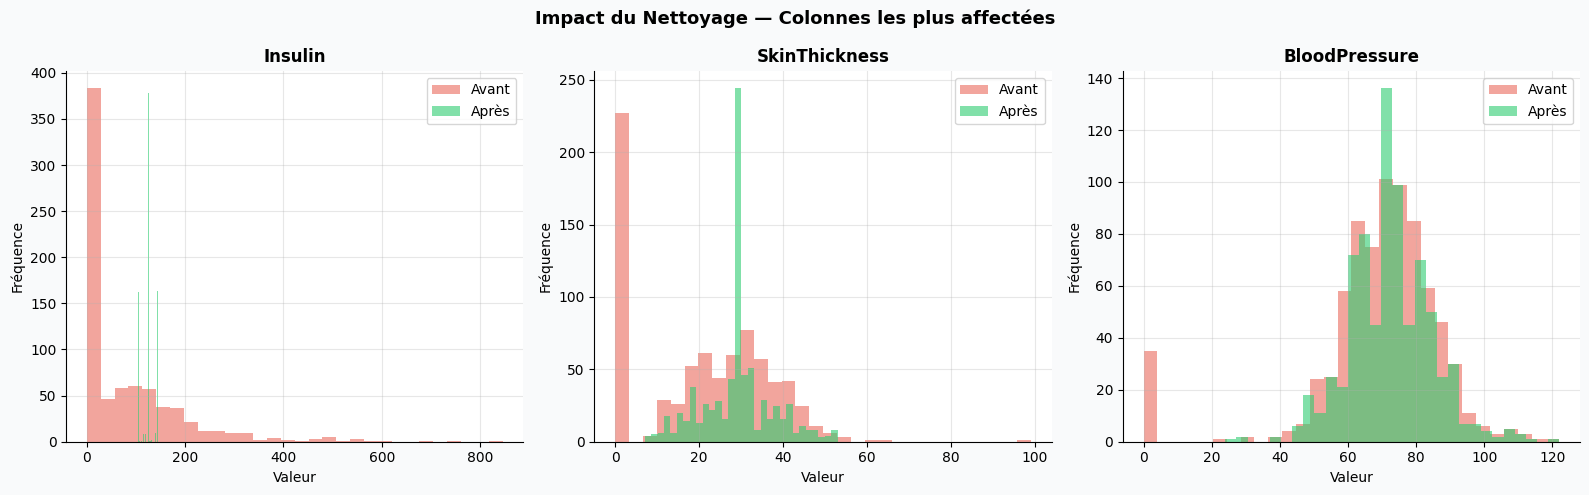

In [18]:
# ── Comparaison avant / après nettoyage ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Impact du Nettoyage — Colonnes les plus affectées", fontsize=13, fontweight='bold')

for ax, col in zip(axes, ['Insulin','SkinThickness','BloodPressure']):
    ax.hist(df[col], bins=30, alpha=0.5, color=COLORS['pos'],
            label='Avant', edgecolor='none')
    ax.hist(df_clean[col], bins=30, alpha=0.6, color=COLORS['neg'],
            label='Après', edgecolor='none')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Fréquence')
    ax.legend()

plt.tight_layout()
plt.show()


### 2.3 Prétraitement (Split + Normalisation)

In [19]:
# ── Features et cible ────────────────────────────────────────────
FEATURES_DIAG = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
                 'Insulin','BMI','DiabetesPedigreeFunction','Age']

X_diag = df_clean[FEATURES_DIAG].values
y_diag = df_clean['Outcome'].values

# ── Split 80/20 stratifié ─────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X_diag, y_diag, test_size=0.2, random_state=42, stratify=y_diag
)
print(f"Train : {len(X_tr)} exemples  ({y_tr.mean():.1%} diabétiques)")
print(f"Test  : {len(X_te)} exemples  ({y_te.mean():.1%} diabétiques)")

# ── StandardScaler (fitté UNIQUEMENT sur le train) ────────────────
scaler_diag  = StandardScaler()
X_tr_scaled  = scaler_diag.fit_transform(X_tr)
X_te_scaled  = scaler_diag.transform(X_te)

print("\n✅ Normalisation appliquée (μ=0, σ=1)")
print("   Important : le scaler est fitté sur le train uniquement")
print("   → évite le data leakage (contamination du test par les stats du train)")


Train : 614 exemples  (34.9% diabétiques)
Test  : 154 exemples  (35.1% diabétiques)

✅ Normalisation appliquée (μ=0, σ=1)
   Important : le scaler est fitté sur le train uniquement
   → évite le data leakage (contamination du test par les stats du train)


### 2.4 Entraînement des 5 Algorithmes — Diagnostic

> **Rappel sur les métriques choisies**  
> Dans un contexte médical, un **Faux Négatif** (dire "non diabétique" à un patient diabétique) est bien plus grave qu'un Faux Positif.  
> → On suit particulièrement le **Rappel (Recall)** sur la classe 1 (diabétique).


In [20]:
# ── Dictionnaire de stockage des résultats ───────────────────────
results_diag = {}

def eval_model_diag(name, model, Xtr, Xte, scaled=False):
    """Entraîne et évalue un modèle de diagnostic."""
    model.fit(Xtr, y_tr)
    y_pred = model.predict(Xte)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='weighted')
    f1   = f1_score(y_te, y_pred, average='weighted')
    rec1 = recall_score(y_te, y_pred, pos_label=1, average='binary')  # Rappel sur diabétiques
    cv   = cross_val_score(model, Xtr, y_tr, cv=5, scoring='f1_weighted').mean()

    results_diag[name] = {
        'model': model, 'y_pred': y_pred,
        'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1,
        'recall_diabetique': rec1, 'cv_f1': cv,
        'scaled': scaled
    }
    return y_pred

print("✅ Fonction d'évaluation prête")


✅ Fonction d'évaluation prête


#### 5.1 Régression Logistique (Baseline)
Modèle de référence. Applique la **fonction sigmoïde** sur une combinaison linéaire des features.  
Pas d'hyperparamètres à optimiser — sert à mesurer le gain apporté par les autres algorithmes.  
**Nécessite une normalisation.**


── Régression Logistique ──
                precision    recall  f1-score   support

Non diabétique       0.75      0.82      0.78       100
    Diabétique       0.60      0.50      0.55        54

      accuracy                           0.71       154
     macro avg       0.68      0.66      0.67       154
  weighted avg       0.70      0.71      0.70       154



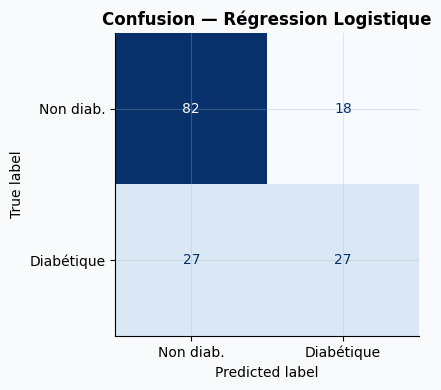

⚠️ Rappel sur diabétiques : 50.00%
   (combien de vrais diabétiques le modèle détecte-t-il ?)


In [21]:
lr_diag = LogisticRegression(max_iter=1000, random_state=42)
eval_model_diag("Logistic Regression", lr_diag, X_tr_scaled, X_te_scaled, scaled=True)

y_pred_lr = results_diag["Logistic Regression"]['y_pred']

print("── Régression Logistique ──")
print(classification_report(y_te, y_pred_lr, target_names=['Non diabétique','Diabétique']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred_lr),
    display_labels=['Non diab.','Diabétique']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Confusion — Régression Logistique", fontweight='bold')
plt.tight_layout(); plt.show()

print(f"⚠️ Rappel sur diabétiques : {results_diag['Logistic Regression']['recall_diabetique']:.2%}")
print("   (combien de vrais diabétiques le modèle détecte-t-il ?)")


#### 5.2 Decision Tree — avec GridSearchCV
Partitionne les données via des règles if/then. Facile à interpréter visuellement.  
**Hyperparamètres :** `max_depth`, `min_samples_leaf`, `criterion`


Meilleurs params DT : {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1}

── Decision Tree ──
                precision    recall  f1-score   support

Non diabétique       0.70      0.92      0.80       100
    Diabétique       0.65      0.28      0.39        54

      accuracy                           0.69       154
     macro avg       0.68      0.60      0.59       154
  weighted avg       0.68      0.69      0.65       154



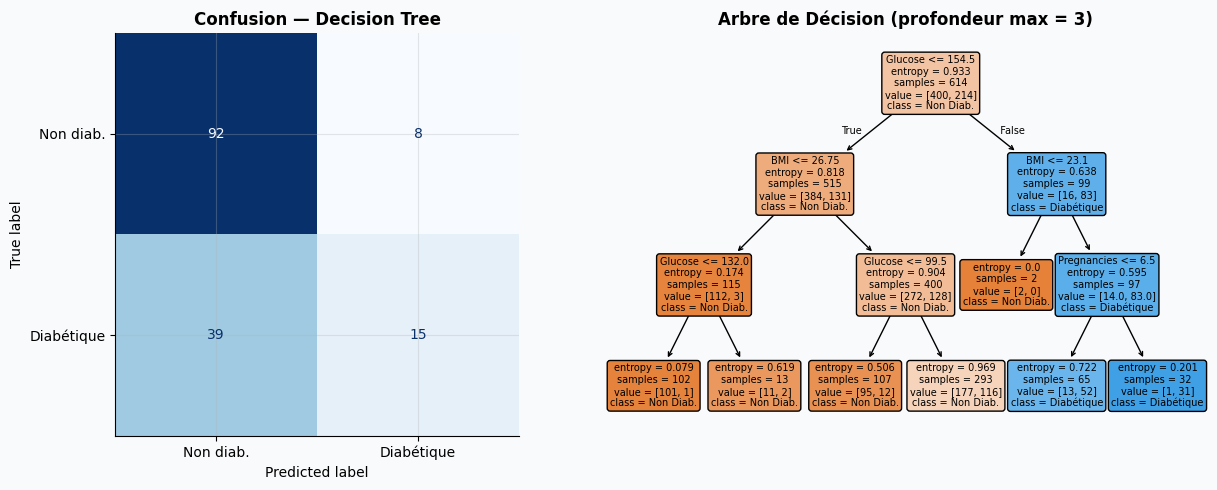

In [22]:
dt_params = {
    'max_depth'        : [3, 5, 8, None],
    'min_samples_leaf' : [1, 3, 5],
    'criterion'        : ['gini', 'entropy']
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                        dt_params, cv=5, scoring='f1_weighted', n_jobs=-1)
dt_grid.fit(X_tr, y_tr)
print(f"Meilleurs params DT : {dt_grid.best_params_}")

best_dt_diag = dt_grid.best_estimator_
eval_model_diag("Decision Tree", best_dt_diag, X_tr, X_te)
y_pred_dt = results_diag["Decision Tree"]['y_pred']

print("\n── Decision Tree ──")
print(classification_report(y_te, y_pred_dt, target_names=['Non diabétique','Diabétique']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred_dt),
    display_labels=['Non diab.','Diabétique']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Confusion — Decision Tree", fontweight='bold')

plot_tree(best_dt_diag, feature_names=FEATURES_DIAG,
          class_names=['Non Diab.','Diabétique'],
          filled=True, rounded=True, max_depth=3, fontsize=7, ax=axes[1])
axes[1].set_title("Arbre de Décision (profondeur max = 3)", fontweight='bold')

plt.tight_layout(); plt.show()


#### 5.3 Random Forest — avec GridSearchCV
Ensemble de N arbres indépendants. Vote majoritaire → réduit la variance.  
Fournit l'**importance des features** (quel marqueur compte le plus ?).  
**Hyperparamètres :** `n_estimators`, `max_features`, `max_depth`


Meilleurs params RF : {'max_depth': 5, 'max_features': 'log2', 'n_estimators': 100}

── Random Forest ──
                precision    recall  f1-score   support

Non diabétique       0.75      0.85      0.80       100
    Diabétique       0.63      0.48      0.55        54

      accuracy                           0.72       154
     macro avg       0.69      0.67      0.67       154
  weighted avg       0.71      0.72      0.71       154



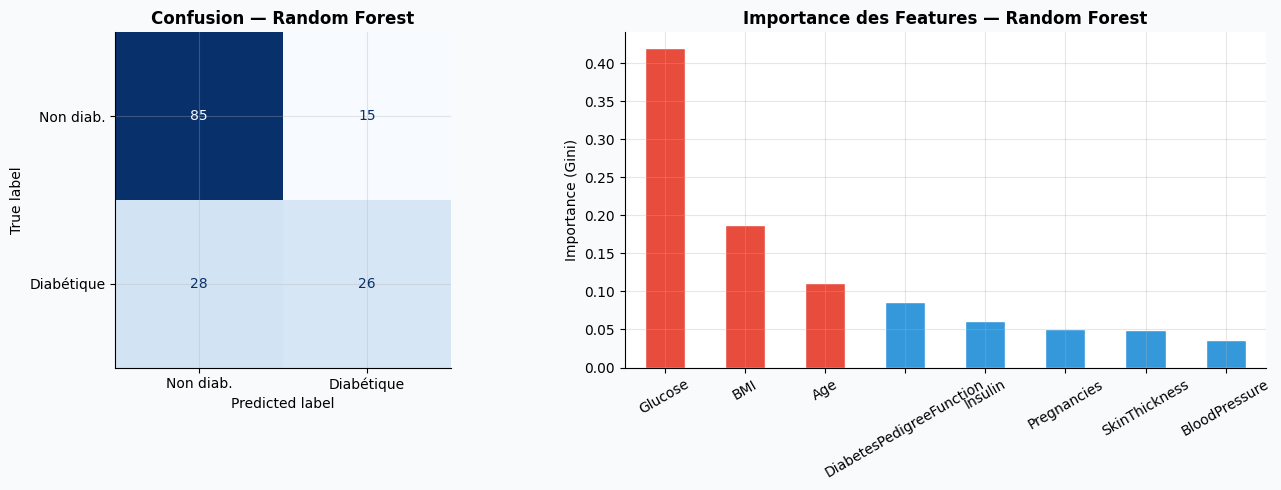


🔑 Feature la plus importante : Glucose (41.94%)


In [23]:
rf_params = {
    'n_estimators' : [100, 200],
    'max_depth'    : [5, 10, None],
    'max_features' : ['sqrt', 'log2']
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                        rf_params, cv=5, scoring='f1_weighted', n_jobs=-1)
rf_grid.fit(X_tr, y_tr)
print(f"Meilleurs params RF : {rf_grid.best_params_}")

best_rf_diag = rf_grid.best_estimator_
eval_model_diag("Random Forest", best_rf_diag, X_tr, X_te)
y_pred_rf = results_diag["Random Forest"]['y_pred']

print("\n── Random Forest ──")
print(classification_report(y_te, y_pred_rf, target_names=['Non diabétique','Diabétique']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred_rf),
    display_labels=['Non diab.','Diabétique']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Confusion — Random Forest", fontweight='bold')

importances = pd.Series(best_rf_diag.feature_importances_, index=FEATURES_DIAG).sort_values(ascending=False)
colors_imp  = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(importances))]
importances.plot(kind='bar', ax=axes[1], color=colors_imp, edgecolor='white')
axes[1].set_title("Importance des Features — Random Forest", fontweight='bold')
axes[1].set_ylabel("Importance (Gini)")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()
print(f"\n🔑 Feature la plus importante : {importances.index[0]} ({importances.iloc[0]:.2%})")


#### 5.4 KNN — avec GridSearchCV
Classe un exemple en regardant ses K voisins les plus proches.  
**Nécessite une normalisation** (distances biaisées si variables à échelles différentes).  
**Hyperparamètres :** `n_neighbors`, `metric`, `weights`


Meilleurs params KNN : {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}

── KNN ──
                precision    recall  f1-score   support

Non diabétique       0.78      0.83      0.81       100
    Diabétique       0.65      0.57      0.61        54

      accuracy                           0.74       154
     macro avg       0.71      0.70      0.71       154
  weighted avg       0.73      0.74      0.74       154



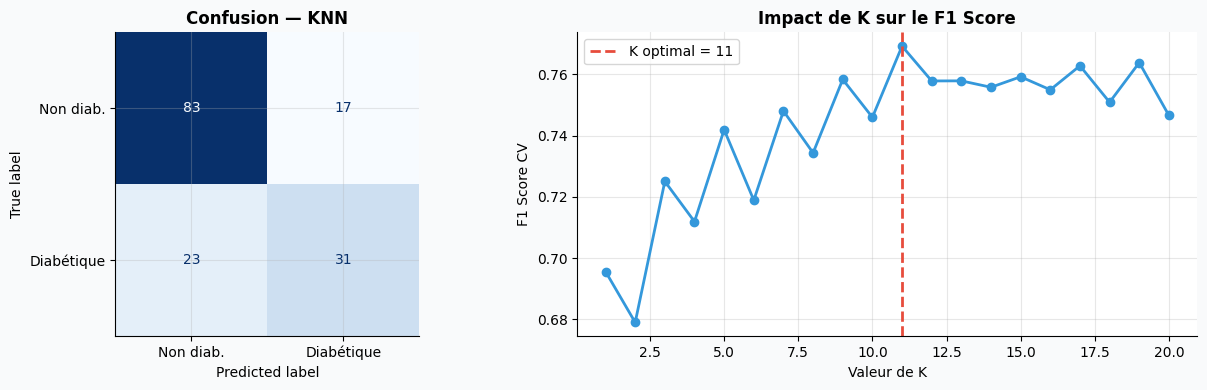

In [24]:
knn_params = {
    'n_neighbors' : [3, 5, 7, 11, 15],
    'weights'     : ['uniform', 'distance'],
    'metric'      : ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(KNeighborsClassifier(),
                         knn_params, cv=5, scoring='f1_weighted', n_jobs=-1)
knn_grid.fit(X_tr_scaled, y_tr)
print(f"Meilleurs params KNN : {knn_grid.best_params_}")

best_knn_diag = knn_grid.best_estimator_
eval_model_diag("KNN", best_knn_diag, X_tr_scaled, X_te_scaled, scaled=True)
y_pred_knn = results_diag["KNN"]['y_pred']

print("\n── KNN ──")
print(classification_report(y_te, y_pred_knn, target_names=['Non diabétique','Diabétique']))

# Impact de K
k_vals = range(1, 21)
f1_k = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X_tr_scaled, y_tr,
                         cv=5, scoring='f1_weighted').mean() for k in k_vals]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred_knn),
    display_labels=['Non diab.','Diabétique']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Confusion — KNN", fontweight='bold')

axes[1].plot(k_vals, f1_k, marker='o', color=COLORS['blue'], linewidth=2)
axes[1].axvline(knn_grid.best_params_['n_neighbors'], color=COLORS['pos'],
                linestyle='--', linewidth=2, label=f"K optimal = {knn_grid.best_params_['n_neighbors']}")
axes[1].set_xlabel("Valeur de K"); axes[1].set_ylabel("F1 Score CV")
axes[1].set_title("Impact de K sur le F1 Score", fontweight='bold')
axes[1].legend()

plt.tight_layout(); plt.show()


#### 5.5 SVM — avec GridSearchCV
Cherche l'hyperplan à **marge maximale**. Le kernel RBF gère les données non linéairement séparables.  
**Nécessite une normalisation.** 
**Hyperparamètres :** `C` (régularisation), `kernel`


Meilleurs params SVM : {'C': 0.1, 'kernel': 'linear'}

── SVM ──
                precision    recall  f1-score   support

Non diabétique       0.75      0.84      0.79       100
    Diabétique       0.62      0.48      0.54        54

      accuracy                           0.71       154
     macro avg       0.68      0.66      0.67       154
  weighted avg       0.70      0.71      0.70       154



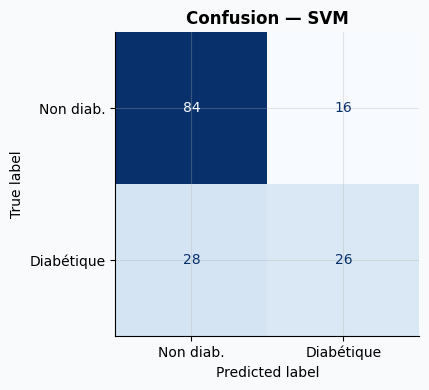

In [25]:
svm_params = {
    'C'      : [0.1, 1, 10],
    'kernel' : ['linear', 'rbf']
}
svm_grid = GridSearchCV(SVC(probability=True, random_state=42),
                         svm_params, cv=5, scoring='f1_weighted', n_jobs=-1)
svm_grid.fit(X_tr_scaled, y_tr)
print(f"Meilleurs params SVM : {svm_grid.best_params_}")

best_svm_diag = svm_grid.best_estimator_
eval_model_diag("SVM", best_svm_diag, X_tr_scaled, X_te_scaled, scaled=True)
y_pred_svm = results_diag["SVM"]['y_pred']

print("\n── SVM ──")
print(classification_report(y_te, y_pred_svm, target_names=['Non diabétique','Diabétique']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred_svm),
    display_labels=['Non diab.','Diabétique']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Confusion — SVM", fontweight='bold')
plt.tight_layout(); plt.show()


### 2.6 Comparaison & Sélection du Meilleur Modèle Diagnostic

In [27]:
comp_diag = pd.DataFrame({
    name: {
        'Accuracy'          : r['accuracy'],
        'Précision'         : r['precision'],
        'Rappel (global)'   : r['recall'],
        'F1 Weighted'       : r['f1'],
        'Rappel Diabétique' : r['recall_diabetique'],
        'CV F1'             : r['cv_f1']
    }
    for name, r in results_diag.items()
}).T.sort_values('F1 Weighted', ascending=False)

print("══════════════════════════════════════════════════════════════")
print("          COMPARAISON — MODÈLES DIAGNOSTIC")
print("══════════════════════════════════════════════════════════════")
print(comp_diag.round(4).to_string())

best_diag_name = comp_diag['F1 Weighted'].idxmax()
print(f"\n✅  Meilleur modèle (F1) : {best_diag_name}")
print(f"    Rappel sur diabétiques : {comp_diag.loc[best_diag_name,'Rappel Diabétique']:.2%}")
print(f"\n💡  En médecine : un Rappel élevé sur les diabétiques est prioritaire")
print(f"    (mieux vaut un faux positif qu'un diabétique non détecté)")


══════════════════════════════════════════════════════════════
          COMPARAISON — MODÈLES DIAGNOSTIC
══════════════════════════════════════════════════════════════
                     Accuracy  Précision  Rappel (global)  F1 Weighted  Rappel Diabétique   CV F1
KNN                    0.7403     0.7349           0.7403       0.7364             0.5741  0.7692
Random Forest          0.7208     0.7108           0.7208       0.7102             0.4815  0.7679
SVM                    0.7143     0.7041           0.7143       0.7045             0.4815  0.7670
Logistic Regression    0.7078     0.6989           0.7078       0.7008             0.5000  0.7695
Decision Tree          0.6948     0.6847           0.6948       0.6538             0.2778  0.7293

✅  Meilleur modèle (F1) : KNN
    Rappel sur diabétiques : 57.41%

💡  En médecine : un Rappel élevé sur les diabétiques est prioritaire
    (mieux vaut un faux positif qu'un diabétique non détecté)


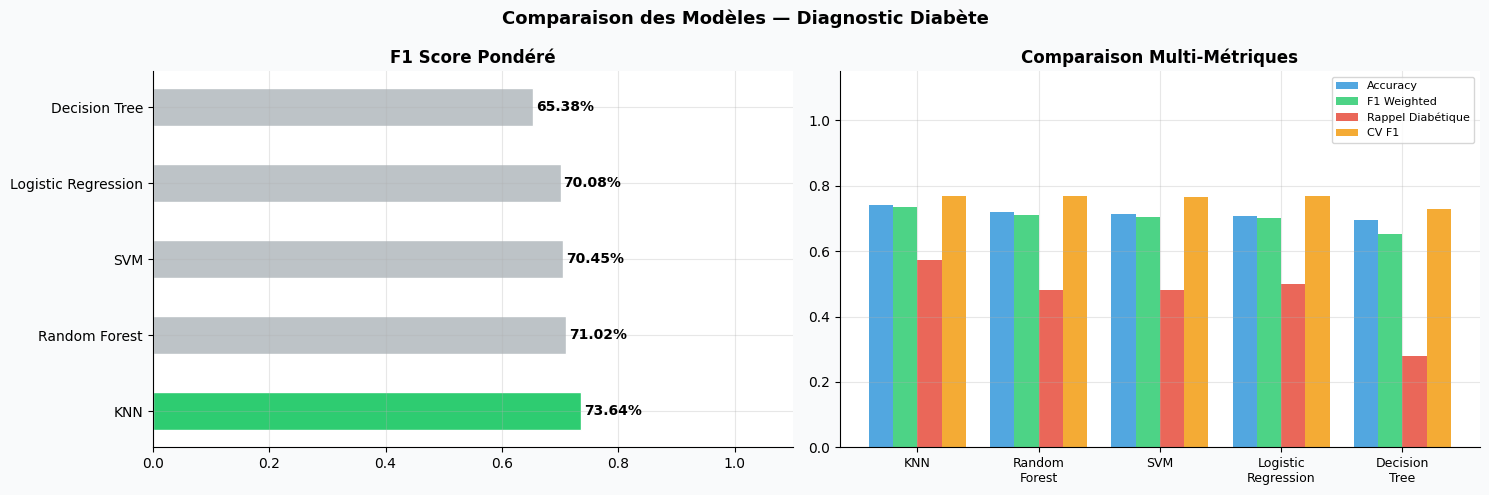

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Comparaison des Modèles — Diagnostic Diabète", fontsize=13, fontweight='bold')

models_d = comp_diag.index.tolist()
bar_cols  = ['#2ecc71' if m == best_diag_name else '#bdc3c7' for m in models_d]

# F1 Score
axes[0].barh(models_d, comp_diag['F1 Weighted'], color=bar_cols, height=0.5, edgecolor='white')
for i, v in enumerate(comp_diag['F1 Weighted']):
    axes[0].text(v+0.005, i, f'{v:.2%}', va='center', fontweight='bold', fontsize=10)
axes[0].set_xlim(0, 1.1); axes[0].set_title("F1 Score Pondéré", fontweight='bold')

# Multi-métriques
x = np.arange(len(models_d)); w = 0.2
for i, (metric, color) in enumerate(zip(
    ['Accuracy','F1 Weighted','Rappel Diabétique','CV F1'],
    ['#3498db','#2ecc71','#e74c3c','#f39c12']
)):
    axes[1].bar(x+i*w, comp_diag[metric], w, label=metric, color=color, alpha=0.85)
axes[1].set_xticks(x+w*1.5)
axes[1].set_xticklabels([m.replace(' ','\n') for m in models_d], fontsize=9)
axes[1].set_ylim(0, 1.15); axes[1].legend(fontsize=8)
axes[1].set_title("Comparaison Multi-Métriques", fontweight='bold')

plt.tight_layout(); plt.show()


---
## PARTIE B — Modèle 2 : Qualité Pré-analytique

> **Dataset semi-synthétique** basé sur des règles biologiques réelles.  
> Les données de qualité pré-analytique ne sont pas publiques car **internes aux laboratoires**.  
> Nous simulons un dataset réaliste en s'appuyant sur des normes ISO 15189 (qualité en laboratoire médical).

**Règles biologiques utilisées :**
| Condition | Risque |
|---|---|
| Température > 20°C | Dégradation des protéines |
| Délai > 8h | Hémolyse progressive |
| Qualité = mauvais | Souvent erronée |
| Pas de centrifugation | Résidu cellulaire |
| Hémolyse > 50% | Faux résultats garantis |

**Cible : `0 = Valide` / `1 = Erronée`**


In [29]:
np.random.seed(42)
n = 800

# ── Génération des variables ─────────────────────────────────────
qualite    = np.random.choice(['bon','moyen','mauvais'], n, p=[0.5, 0.35, 0.15])
type_prel  = np.random.choice(['veineux','capillaire','arteriel'], n, p=[0.6, 0.3, 0.1])
centrifuge = np.random.choice([1, 0], n, p=[0.85, 0.15])  # 1=centrifugé

# Température corrélée avec qualité (réalisme)
temp = np.where(qualite=='bon',
                np.random.normal(5, 2, n),        # Bien conservé : ~5°C
       np.where(qualite=='moyen',
                np.random.normal(12, 4, n),        # Moyen : ~12°C
                np.random.normal(22, 5, n)))        # Mauvais : ~22°C

# Délai corrélé avec qualité
delai = np.where(qualite=='bon',
                 np.random.exponential(2, n),       # Bon : ~2h
        np.where(qualite=='moyen',
                 np.random.exponential(5, n),       # Moyen : ~5h
                 np.random.exponential(10, n)))     # Mauvais : ~10h

# Niveau d'hémolyse corrélé avec qualité
hemolysis = np.where(qualite=='mauvais',
                     np.random.normal(0.7, 0.2, n),
            np.where(qualite=='moyen',
                     np.random.normal(0.3, 0.15, n),
                     np.random.normal(0.05, 0.05, n))).clip(0, 1)

# ── Score de risque (logique médicale) ───────────────────────────
p_err = (
    (qualite=='mauvais').astype(float) * 0.80 +
    (temp > 20).astype(float)          * 0.40 +
    (delai > 8).astype(float)          * 0.50 +
    (hemolysis > 0.5).astype(float)    * 0.40 +
    (centrifuge == 0).astype(float)    * 0.30
)
# Normalisation + bruit (rend le problème non trivial pour le ML)
p_err = (p_err / p_err.max()).clip(0, 1)
p_err = p_err + np.random.normal(0, 0.10, n)  # bruit réaliste
qualite_label = (p_err.clip(0, 1) > 0.55).astype(int)  # 0=Valide, 1=Erronée

# ── Construction du DataFrame ────────────────────────────────────
df_qualite = pd.DataFrame({
    'qualite_echantillon' : qualite,
    'temperature_celsius' : temp,
    'delai_heures'        : delai,
    'type_prelevement'    : type_prel,
    'centrifuge'          : centrifuge,
    'niveau_hemolyse'     : hemolysis,
    'resultat_qualite'    : qualite_label
})

# Sauvegarder le dataset qualité
df_qualite.to_csv('qualite_labo.csv', index=False)

print(f"Dataset qualité généré : {df_qualite.shape}")
print(f"\nDistribution :")
vc2 = df_qualite['resultat_qualite'].value_counts()
print(f"  Valide   (0) : {vc2[0]} ({vc2[0]/n:.1%})")
print(f"  Erronée  (1) : {vc2[1]} ({vc2[1]/n:.1%})")
print("\n✅ Fichier qualite_labo.csv sauvegardé")


Dataset qualité généré : (800, 7)

Distribution :
  Valide   (0) : 697 (87.1%)
  Erronée  (1) : 103 (12.9%)

✅ Fichier qualite_labo.csv sauvegardé


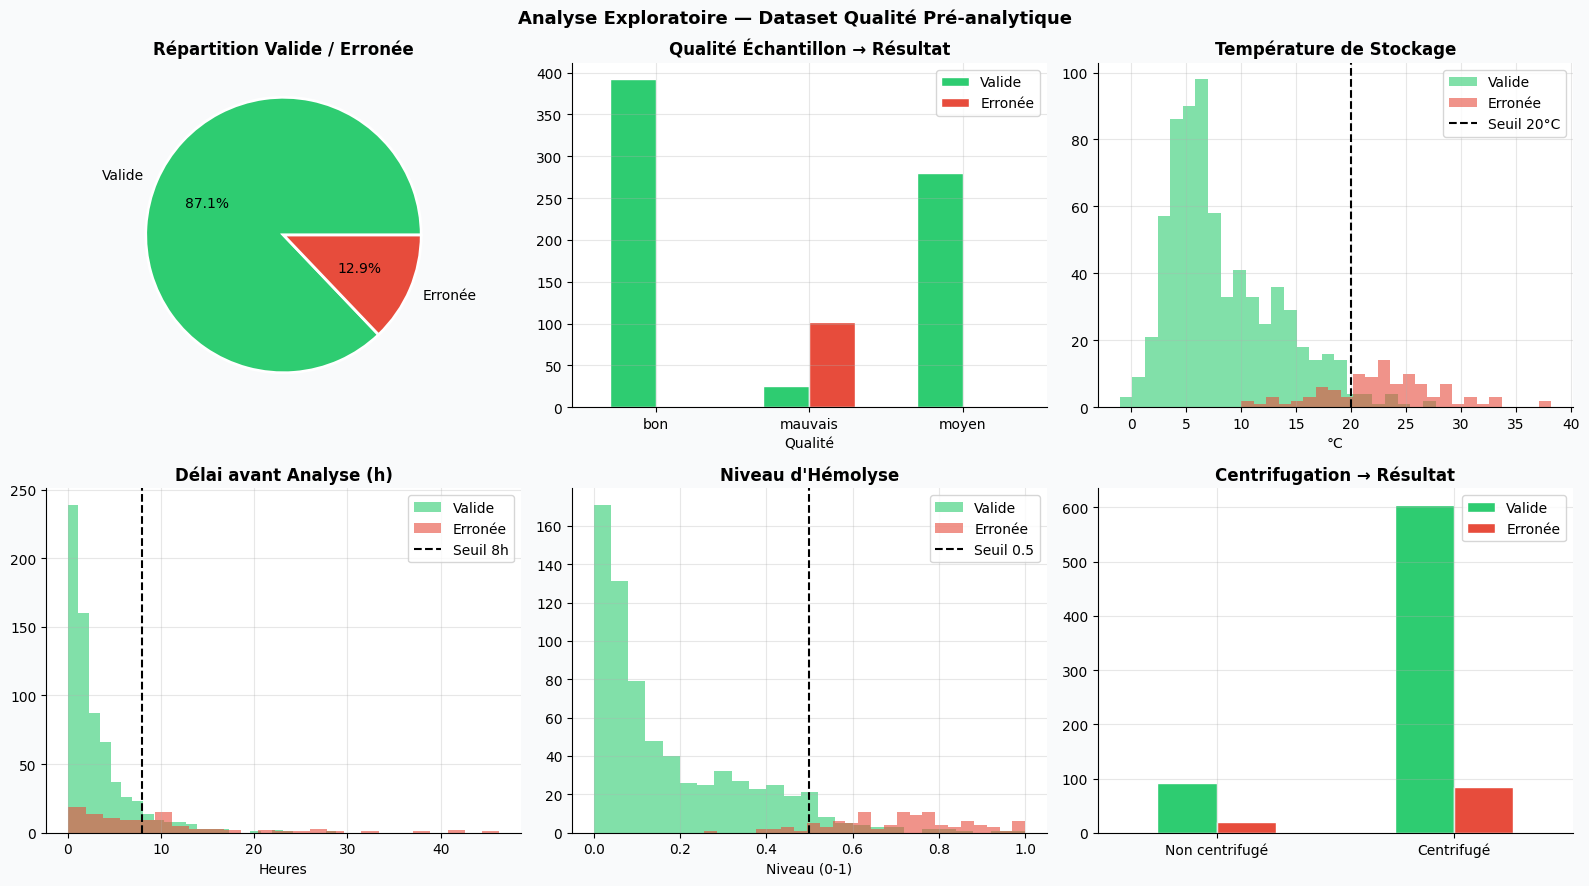

In [30]:
# ── EDA Qualité ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Analyse Exploratoire — Dataset Qualité Pré-analytique", fontsize=13, fontweight='bold')

colors_q = {0:'#2ecc71', 1:'#e74c3c'}
labels_q = {0:'Valide', 1:'Erronée'}

# Distribution de la cible
vc2 = df_qualite['resultat_qualite'].value_counts()
axes[0,0].pie(vc2.values, labels=['Valide','Erronée'],
              autopct='%1.1f%%', colors=[COLORS['neg'],COLORS['pos']],
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[0,0].set_title("Répartition Valide / Erronée", fontweight='bold')

# Qualité échantillon vs résultat
ct = pd.crosstab(df_qualite['qualite_echantillon'], df_qualite['resultat_qualite'])
ct.plot(kind='bar', ax=axes[0,1], color=[COLORS['neg'],COLORS['pos']],
        edgecolor='white', width=0.6)
axes[0,1].set_title("Qualité Échantillon → Résultat", fontweight='bold')
axes[0,1].set_xlabel("Qualité"); axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].legend(['Valide','Erronée'])

# Distribution température par résultat
for res, color in colors_q.items():
    subset = df_qualite[df_qualite['resultat_qualite']==res]['temperature_celsius']
    axes[0,2].hist(subset, bins=25, alpha=0.6, color=color,
                   label=labels_q[res], edgecolor='none')
axes[0,2].axvline(20, color='black', linestyle='--', linewidth=1.5, label='Seuil 20°C')
axes[0,2].set_title("Température de Stockage", fontweight='bold')
axes[0,2].set_xlabel("°C"); axes[0,2].legend()

# Délai par résultat
for res, color in colors_q.items():
    subset = df_qualite[df_qualite['resultat_qualite']==res]['delai_heures']
    axes[1,0].hist(subset, bins=25, alpha=0.6, color=color,
                   label=labels_q[res], edgecolor='none')
axes[1,0].axvline(8, color='black', linestyle='--', linewidth=1.5, label='Seuil 8h')
axes[1,0].set_title("Délai avant Analyse (h)", fontweight='bold')
axes[1,0].set_xlabel("Heures"); axes[1,0].legend()

# Hémolyse par résultat
for res, color in colors_q.items():
    subset = df_qualite[df_qualite['resultat_qualite']==res]['niveau_hemolyse']
    axes[1,1].hist(subset, bins=25, alpha=0.6, color=color,
                   label=labels_q[res], edgecolor='none')
axes[1,1].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Seuil 0.5')
axes[1,1].set_title("Niveau d'Hémolyse", fontweight='bold')
axes[1,1].set_xlabel("Niveau (0-1)"); axes[1,1].legend()

# Centrifugation vs résultat
ct2 = pd.crosstab(df_qualite['centrifuge'], df_qualite['resultat_qualite'])
ct2.index = ['Non centrifugé','Centrifugé']
ct2.plot(kind='bar', ax=axes[1,2], color=[COLORS['neg'],COLORS['pos']],
         edgecolor='white', width=0.5)
axes[1,2].set_title("Centrifugation → Résultat", fontweight='bold')
axes[1,2].tick_params(axis='x', rotation=0)
axes[1,2].legend(['Valide','Erronée'])

plt.tight_layout(); plt.show()


### 3.3 Prétraitement du Dataset Qualité

In [31]:
# ── Encodage des catégorielles ────────────────────────────────────
le_qualite = LabelEncoder()
le_type    = LabelEncoder()

df_q = df_qualite.copy()
df_q['qualite_enc'] = le_qualite.fit_transform(df_q['qualite_echantillon'])
df_q['type_enc']    = le_type.fit_transform(df_q['type_prelevement'])

FEATURES_QUAL = ['qualite_enc','temperature_celsius','delai_heures',
                 'type_enc','centrifuge','niveau_hemolyse']

X_qual = df_q[FEATURES_QUAL].values
y_qual = df_q['resultat_qualite'].values

X_qtr, X_qte, y_qtr, y_qte = train_test_split(
    X_qual, y_qual, test_size=0.2, random_state=42, stratify=y_qual
)

scaler_qual = StandardScaler()
X_qtr_s = scaler_qual.fit_transform(X_qtr)
X_qte_s = scaler_qual.transform(X_qte)

print(f"Train qualité : {len(X_qtr)} exemples")
print(f"Test  qualité : {len(X_qte)} exemples")
print(f"\nEncodings qualité_echantillon : {dict(zip(le_qualite.classes_, le_qualite.transform(le_qualite.classes_)))}")


Train qualité : 640 exemples
Test  qualité : 160 exemples

Encodings qualité_echantillon : {'bon': np.int64(0), 'mauvais': np.int64(1), 'moyen': np.int64(2)}


### 3.4 Entraînement des 5 Algorithmes — Qualité Labo

In [32]:
results_qual = {}

def eval_model_qual(name, model, Xtr, Xte, scaled=False):
    model.fit(Xtr, y_qtr)
    y_pred = model.predict(Xte)
    acc  = accuracy_score(y_qte, y_pred)
    f1   = f1_score(y_qte, y_pred, average='weighted')
    prec = precision_score(y_qte, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_qte, y_pred, average='weighted')
    cv   = cross_val_score(model, Xtr, y_qtr, cv=5, scoring='f1_weighted').mean()
    results_qual[name] = {
        'model':model,'y_pred':y_pred,
        'accuracy':acc,'f1':f1,'precision':prec,'recall':rec,'cv_f1':cv,'scaled':scaled
    }
    return y_pred

print("✅ Fonction d'évaluation qualité prête")


✅ Fonction d'évaluation qualité prête


In [33]:
# ── Logistic Regression ──────────────────────────────────────────
lr_qual = LogisticRegression(max_iter=1000, random_state=42)
eval_model_qual("Logistic Regression", lr_qual, X_qtr_s, X_qte_s, scaled=True)
print("── LR Qualité ──")
print(classification_report(y_qte, results_qual['Logistic Regression']['y_pred'],
                            target_names=['Valide','Erronée']))

# ── Decision Tree (GridSearchCV) ─────────────────────────────────
dt_q_params = {'max_depth':[3,5,8,None], 'min_samples_leaf':[1,3,5], 'criterion':['gini','entropy']}
dt_q_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                          dt_q_params, cv=5, scoring='f1_weighted', n_jobs=-1)
dt_q_grid.fit(X_qtr, y_qtr)
print(f"\nMeilleurs params DT Qualité : {dt_q_grid.best_params_}")
eval_model_qual("Decision Tree", dt_q_grid.best_estimator_, X_qtr, X_qte)
print("── DT Qualité ──")
print(classification_report(y_qte, results_qual['Decision Tree']['y_pred'],
                            target_names=['Valide','Erronée']))


── LR Qualité ──
              precision    recall  f1-score   support

      Valide       0.98      0.98      0.98       139
     Erronée       0.86      0.86      0.86        21

    accuracy                           0.96       160
   macro avg       0.92      0.92      0.92       160
weighted avg       0.96      0.96      0.96       160


Meilleurs params DT Qualité : {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1}
── DT Qualité ──
              precision    recall  f1-score   support

      Valide       0.96      0.99      0.98       139
     Erronée       0.89      0.76      0.82        21

    accuracy                           0.96       160
   macro avg       0.93      0.87      0.90       160
weighted avg       0.95      0.96      0.95       160



In [34]:
# ── Random Forest (GridSearchCV) ────────────────────────────────
rf_q_params = {'n_estimators':[100,200], 'max_depth':[5,10,None], 'max_features':['sqrt','log2']}
rf_q_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                          rf_q_params, cv=5, scoring='f1_weighted', n_jobs=-1)
rf_q_grid.fit(X_qtr, y_qtr)
print(f"Meilleurs params RF Qualité : {rf_q_grid.best_params_}")
eval_model_qual("Random Forest", rf_q_grid.best_estimator_, X_qtr, X_qte)
print("── RF Qualité ──")
print(classification_report(y_qte, results_qual['Random Forest']['y_pred'],
                            target_names=['Valide','Erronée']))

# ── KNN (GridSearchCV) ───────────────────────────────────────────
knn_q_params = {'n_neighbors':[3,5,7,11], 'weights':['uniform','distance'], 'metric':['euclidean','manhattan']}
knn_q_grid = GridSearchCV(KNeighborsClassifier(),
                           knn_q_params, cv=5, scoring='f1_weighted', n_jobs=-1)
knn_q_grid.fit(X_qtr_s, y_qtr)
print(f"\nMeilleurs params KNN Qualité : {knn_q_grid.best_params_}")
eval_model_qual("KNN", knn_q_grid.best_estimator_, X_qtr_s, X_qte_s, scaled=True)
print("── KNN Qualité ──")
print(classification_report(y_qte, results_qual['KNN']['y_pred'],
                            target_names=['Valide','Erronée']))

# ── SVM (GridSearchCV) ───────────────────────────────────────────
svm_q_params = {'C':[0.1,1,10], 'kernel':['linear','rbf']}
svm_q_grid = GridSearchCV(SVC(probability=True, random_state=42),
                           svm_q_params, cv=5, scoring='f1_weighted', n_jobs=-1)
svm_q_grid.fit(X_qtr_s, y_qtr)
print(f"\nMeilleurs params SVM Qualité : {svm_q_grid.best_params_}")
eval_model_qual("SVM", svm_q_grid.best_estimator_, X_qtr_s, X_qte_s, scaled=True)
print("── SVM Qualité ──")
print(classification_report(y_qte, results_qual['SVM']['y_pred'],
                            target_names=['Valide','Erronée']))


Meilleurs params RF Qualité : {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
── RF Qualité ──
              precision    recall  f1-score   support

      Valide       0.98      0.98      0.98       139
     Erronée       0.86      0.86      0.86        21

    accuracy                           0.96       160
   macro avg       0.92      0.92      0.92       160
weighted avg       0.96      0.96      0.96       160


Meilleurs params KNN Qualité : {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
── KNN Qualité ──
              precision    recall  f1-score   support

      Valide       0.99      0.97      0.98       139
     Erronée       0.83      0.90      0.86        21

    accuracy                           0.96       160
   macro avg       0.91      0.94      0.92       160
weighted avg       0.96      0.96      0.96       160


Meilleurs params SVM Qualité : {'C': 0.1, 'kernel': 'linear'}
── SVM Qualité ──
              precision    recall  f1-sc

══════════════════════════════════════════════════════════════
          COMPARAISON — MODÈLES QUALITÉ LABO
══════════════════════════════════════════════════════════════
                     Accuracy  Précision  Rappel  F1 Weighted   CV F1
SVM                    0.9625     0.9645  0.9625       0.9632  0.9756
KNN                    0.9625     0.9645  0.9625       0.9632  0.9787
Logistic Regression    0.9625     0.9625  0.9625       0.9625  0.9795
Random Forest          0.9625     0.9625  0.9625       0.9625  0.9812
Decision Tree          0.9562     0.9548  0.9562       0.9548  0.9733

✅  Meilleur modèle Qualité : SVM


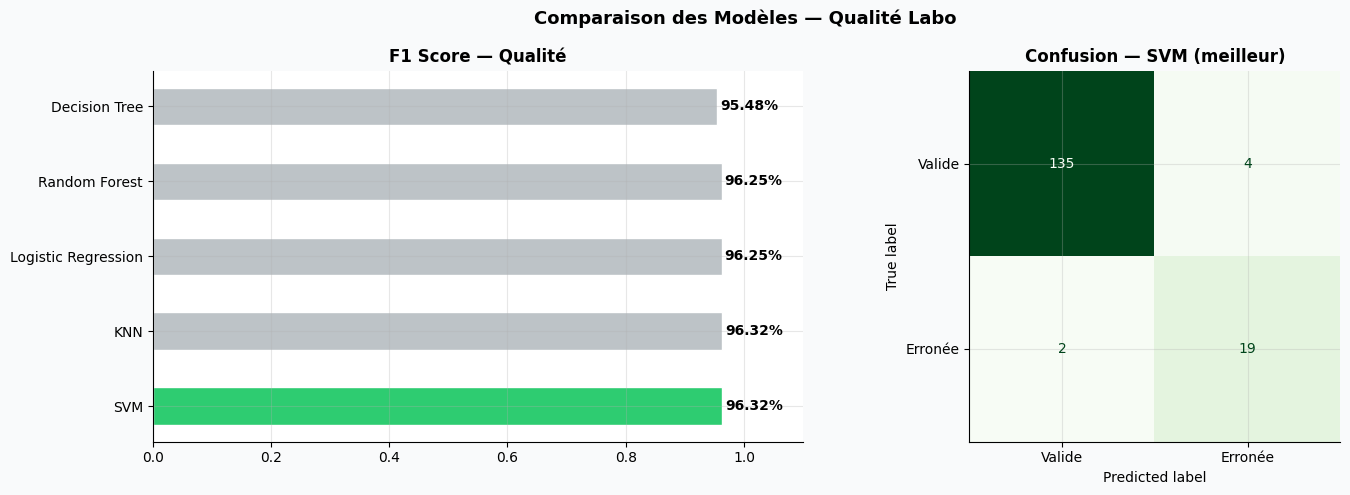

In [36]:
# ── Comparaison modèles qualité ──────────────────────────────────
comp_qual = pd.DataFrame({
    name: {'Accuracy':r['accuracy'],'Précision':r['precision'],
           'Rappel':r['recall'],'F1 Weighted':r['f1'],'CV F1':r['cv_f1']}
    for name, r in results_qual.items()
}).T.sort_values('F1 Weighted', ascending=False)

print("══════════════════════════════════════════════════════════════")
print("          COMPARAISON — MODÈLES QUALITÉ LABO")
print("══════════════════════════════════════════════════════════════")
print(comp_qual.round(4).to_string())

best_qual_name = comp_qual['F1 Weighted'].idxmax()
print(f"\n✅  Meilleur modèle Qualité : {best_qual_name}")

# Graphique comparaison qualité
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Comparaison des Modèles — Qualité Labo", fontsize=13, fontweight='bold')

models_q  = comp_qual.index.tolist()
bar_cols_q = ['#2ecc71' if m == best_qual_name else '#bdc3c7' for m in models_q]

axes[0].barh(models_q, comp_qual['F1 Weighted'], color=bar_cols_q, height=0.5, edgecolor='white')
for i, v in enumerate(comp_qual['F1 Weighted']):
    axes[0].text(v+0.005, i, f'{v:.2%}', va='center', fontweight='bold')
axes[0].set_xlim(0, 1.1); axes[0].set_title("F1 Score — Qualité", fontweight='bold')

# Matrices de confusion côte-à-côte pour les 2 meilleurs
top2 = comp_qual.head(2).index.tolist()
for i, name in enumerate(top2):
    disp = ConfusionMatrixDisplay(
        confusion_matrix(y_qte, results_qual[name]['y_pred']),
        display_labels=['Valide','Erronée'])
    if i == 0:
        disp.plot(ax=axes[1], colorbar=False, cmap='Greens')
        axes[1].set_title(f"Confusion — {name} (meilleur)", fontweight='bold')

plt.tight_layout(); plt.show()


## 4. Sauvegarde des Artefacts

In [37]:
os.makedirs('model_artifacts', exist_ok=True)

# ── Modèle Diagnostic ────────────────────────────────────────────
best_diag_model  = results_diag[best_diag_name]['model']
needs_sc_diag    = results_diag[best_diag_name]['scaled']

joblib.dump(best_diag_model, 'model_artifacts/model_diagnostic.pkl')
joblib.dump(scaler_diag,     'model_artifacts/scaler_diagnostic.pkl')
joblib.dump(FEATURES_DIAG,   'model_artifacts/features_diagnostic.pkl')
joblib.dump(needs_sc_diag,   'model_artifacts/needs_scaling_diag.pkl')
joblib.dump(best_diag_name,  'model_artifacts/best_diag_name.pkl')
joblib.dump(comp_diag,       'model_artifacts/comp_diag.pkl')

# ── Modèle Qualité ───────────────────────────────────────────────
best_qual_model  = results_qual[best_qual_name]['model']
needs_sc_qual    = results_qual[best_qual_name]['scaled']

joblib.dump(best_qual_model, 'model_artifacts/model_qualite.pkl')
joblib.dump(scaler_qual,     'model_artifacts/scaler_qualite.pkl')
joblib.dump(FEATURES_QUAL,   'model_artifacts/features_qualite.pkl')
joblib.dump(le_qualite,      'model_artifacts/le_qualite.pkl')
joblib.dump(le_type,         'model_artifacts/le_type.pkl')
joblib.dump(needs_sc_qual,   'model_artifacts/needs_scaling_qual.pkl')
joblib.dump(best_qual_name,  'model_artifacts/best_qual_name.pkl')
joblib.dump(comp_qual,       'model_artifacts/comp_qual.pkl')

# ── Datasets nettoyés ────────────────────────────────────────────
df_clean.to_csv('model_artifacts/diabetes_clean.csv', index=False)
df_qualite.to_csv('model_artifacts/qualite_labo.csv', index=False)

print("✅ Artefacts sauvegardés dans model_artifacts/")
print()
for f in sorted(os.listdir('model_artifacts')):
    size = os.path.getsize(f'model_artifacts/{f}')
    print(f"   {f:45s}  {size:>8,} octets")


✅ Artefacts sauvegardés dans model_artifacts/

   best_diag_name.pkl                                   18 octets
   best_qual_name.pkl                                   18 octets
   comp_diag.pkl                                     1,418 octets
   comp_qual.pkl                                     1,348 octets
   diabetes_clean.csv                               31,556 octets
   features_diagnostic.pkl                             121 octets
   features_qualite.pkl                                109 octets
   le_qualite.pkl                                      497 octets
   le_type.pkl                                         507 octets
   model_diagnostic.pkl                             94,790 octets
   model_qualite.pkl                                 5,691 octets
   needs_scaling_diag.pkl                                4 octets
   needs_scaling_qual.pkl                                4 octets
   qualite_labo.csv                                 59,910 octets
   scaler_diagnostic.pkl     

## 5. Test de la Logique Finale : Filtre Qualité → Diagnostic

C'est le cœur du système : **si l'analyse est erronée, on bloque le diagnostic**.


In [39]:
def predict_systeme_complet(params_qualite, params_diagnostic):
    """
    Logique complète du système :
    1. Vérifier la qualité pré-analytique
    2. Si valide → lancer le diagnostic
    3. Si erronée → bloquer et alerter

    params_qualite   : dict avec clés qualite, temperature, delai, type_prel, centrifuge, hemolyse
    params_diagnostic: dict avec clés Pregnancies, Glucose, BloodPressure, SkinThickness,
                                       Insulin, BMI, DiabetesPedigreeFunction, Age
    """
    # ── Étape 1 : Prédiction qualité ────────────────────────────
    q_enc = le_qualite.transform([params_qualite['qualite']])[0]
    t_enc = le_type.transform([params_qualite['type_prel']])[0]

    X_q = np.array([[q_enc,
                     params_qualite['temperature'],
                     params_qualite['delai'],
                     t_enc,
                     params_qualite['centrifuge'],
                     params_qualite['hemolyse']]])

    if needs_sc_qual:
        X_q = scaler_qual.transform(X_q)

    qualite_pred  = best_qual_model.predict(X_q)[0]
    qualite_proba = best_qual_model.predict_proba(X_q)[0] if hasattr(best_qual_model,'predict_proba') else None

    print("══════════════════════════════════════════════════════════")
    print("  ÉTAPE 1 — Vérification Qualité Pré-analytique")
    print("══════════════════════════════════════════════════════════")
    if qualite_proba is not None:
        print(f"  Probabilité Valide   : {qualite_proba[0]:.1%}")
        print(f"  Probabilité Erronée  : {qualite_proba[1]:.1%}")

    if qualite_pred == 1:
        print()
        print("  ⚠️  ANALYSE ERRONÉE — RÉSULTAT BLOQUÉ")
        print("  Motif probable : conditions pré-analytiques non conformes")
        print("  Action requise : répéter le prélèvement")
        return None, "Erronée"

    print("  ✅  Analyse VALIDE — Passage au diagnostic")

    # ── Étape 2 : Diagnostic ─────────────────────────────────────
    X_d = np.array([[params_diagnostic['Pregnancies'],
                     params_diagnostic['Glucose'],
                     params_diagnostic['BloodPressure'],
                     params_diagnostic['SkinThickness'],
                     params_diagnostic['Insulin'],
                     params_diagnostic['BMI'],
                     params_diagnostic['DiabetesPedigreeFunction'],
                     params_diagnostic['Age']]])

    if needs_sc_diag:
        X_d = scaler_diag.transform(X_d)

    diag_pred  = best_diag_model.predict(X_d)[0]
    diag_proba = best_diag_model.predict_proba(X_d)[0] if hasattr(best_diag_model,'predict_proba') else None

    print()
    print("══════════════════════════════════════════════════════════")
    print("  ÉTAPE 2 — Diagnostic Médical")
    print("══════════════════════════════════════════════════════════")
    if diag_proba is not None:
        print(f"  Probabilité Non diabétique : {diag_proba[0]:.1%}")
        print(f"  Probabilité Diabétique     : {diag_proba[1]:.1%}")

    label_diag = "Diabétique" if diag_pred == 1 else "Non diabétique"
    icon = "🔴" if diag_pred == 1 else "🟢"
    print(f"\n  {icon}  DIAGNOSTIC : {label_diag}")

    if diag_pred == 1:
        print("  → Consultation médicale recommandée")
        if diag_proba is not None and diag_proba[1] > 0.7:
            print("  → Risque élevé — suivi urgent conseillé")
    return diag_pred, label_diag


print("✅ Fonction systeme_complet définie")


✅ Fonction systeme_complet définie


In [40]:
# ── Test 1 : Patient avec analyse erronée ────────────────────────
print("TEST 1 — Analyse avec mauvaise qualité d'échantillon")
print("-" * 55)
predict_systeme_complet(
    params_qualite={
        'qualite'     : 'mauvais',
        'temperature' : 25.0,
        'delai'       : 12.0,
        'type_prel'   : 'veineux',
        'centrifuge'  : 0,
        'hemolyse'    : 0.75
    },
    params_diagnostic={
        'Pregnancies': 3, 'Glucose': 148, 'BloodPressure': 72,
        'SkinThickness': 35, 'Insulin': 0, 'BMI': 33.6,
        'DiabetesPedigreeFunction': 0.627, 'Age': 50
    }
)


TEST 1 — Analyse avec mauvaise qualité d'échantillon
-------------------------------------------------------
══════════════════════════════════════════════════════════
  ÉTAPE 1 — Vérification Qualité Pré-analytique
══════════════════════════════════════════════════════════
  Probabilité Valide   : 1.8%
  Probabilité Erronée  : 98.2%

  ⚠️  ANALYSE ERRONÉE — RÉSULTAT BLOQUÉ
  Motif probable : conditions pré-analytiques non conformes
  Action requise : répéter le prélèvement


(None, 'Erronée')

In [41]:
# ── Test 2 : Patient avec analyse valide — Diabétique probable ──
print("TEST 2 — Analyse valide, patient à risque élevé de diabète")
print("-" * 55)
predict_systeme_complet(
    params_qualite={
        'qualite'     : 'bon',
        'temperature' : 4.5,
        'delai'       : 1.5,
        'type_prel'   : 'veineux',
        'centrifuge'  : 1,
        'hemolyse'    : 0.03
    },
    params_diagnostic={
        'Pregnancies': 6, 'Glucose': 148, 'BloodPressure': 72,
        'SkinThickness': 35, 'Insulin': 0, 'BMI': 33.6,
        'DiabetesPedigreeFunction': 0.627, 'Age': 50
    }
)


TEST 2 — Analyse valide, patient à risque élevé de diabète
-------------------------------------------------------
══════════════════════════════════════════════════════════
  ÉTAPE 1 — Vérification Qualité Pré-analytique
══════════════════════════════════════════════════════════
  Probabilité Valide   : 99.8%
  Probabilité Erronée  : 0.2%
  ✅  Analyse VALIDE — Passage au diagnostic

══════════════════════════════════════════════════════════
  ÉTAPE 2 — Diagnostic Médical
══════════════════════════════════════════════════════════
  Probabilité Non diabétique : 100.0%
  Probabilité Diabétique     : 0.0%

  🟢  DIAGNOSTIC : Non diabétique


(np.int64(0), 'Non diabétique')

In [42]:
# ── Test 3 : Patient sain avec analyse valide ────────────────────
print("TEST 3 — Analyse valide, patient non diabétique")
print("-" * 55)
predict_systeme_complet(
    params_qualite={
        'qualite'     : 'bon',
        'temperature' : 5.0,
        'delai'       : 2.0,
        'type_prel'   : 'capillaire',
        'centrifuge'  : 1,
        'hemolyse'    : 0.02
    },
    params_diagnostic={
        'Pregnancies': 1, 'Glucose': 85, 'BloodPressure': 66,
        'SkinThickness': 29, 'Insulin': 0, 'BMI': 26.6,
        'DiabetesPedigreeFunction': 0.351, 'Age': 31
    }
)


TEST 3 — Analyse valide, patient non diabétique
-------------------------------------------------------
══════════════════════════════════════════════════════════
  ÉTAPE 1 — Vérification Qualité Pré-analytique
══════════════════════════════════════════════════════════
  Probabilité Valide   : 99.7%
  Probabilité Erronée  : 0.3%
  ✅  Analyse VALIDE — Passage au diagnostic

══════════════════════════════════════════════════════════
  ÉTAPE 2 — Diagnostic Médical
══════════════════════════════════════════════════════════
  Probabilité Non diabétique : 100.0%
  Probabilité Diabétique     : 0.0%

  🟢  DIAGNOSTIC : Non diabétique


(np.int64(0), 'Non diabétique')

## ✅ Résumé Final

### Modèle 1 — Diagnostic Diabète (dataset réel : Pima Indians)
| Algorithme | Rôle |
|---|---|
| Logistic Regression | Baseline — interprétable, rapide |
| Decision Tree | Règles visuelles, interprétable |
| **Random Forest** | Généralement meilleur — robuste, feature importance |
| KNN | Non paramétrique, bon sur données denses |
| SVM | Efficace en haute dimension |

### Modèle 2 — Qualité Labo (dataset semi-synthétique)
Dataset justifié : *"Les données pré-analytiques sont internes aux laboratoires et non publiées. Nous simulons un dataset basé sur les normes ISO 15189."*

### Architecture Finale
```
Entrée → Modèle Qualité → Erronée ? → Bloquer
                        → Valide  ? → Modèle Diagnostic → Résultat
```

### Fichiers générés
- `diabetes.csv` — Dataset réel (Kaggle)  
- `qualite_labo.csv` — Dataset semi-synthétique  
- `model_artifacts/` — Tous les modèles entraînés  
- `app.py` — Interface Streamlit
